In [1]:
!pip -q install aif360 shap fairlearn scikit-learn matplotlib pandas seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 10.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import shap

In [3]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df = df.replace("?", np.nan)

target = "class"

X = df.drop(columns=[target])
y = (df[target] == ">50K").astype(int)

categorical = X.select_dtypes(include=["object","category"]).columns
numeric = X.select_dtypes(exclude=["object","category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer",SimpleImputer(strategy="median"))
            ]),
            numeric
        ),
        (
            "cat",
            Pipeline([
                ("imputer",SimpleImputer(strategy="most_frequent")),
                ("onehot",OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical
        )
    ]
)

In [5]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model=Pipeline([
    ("prep",preprocessor),
    ("model",LogisticRegression(max_iter=1000))
])

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.8507523799774798


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


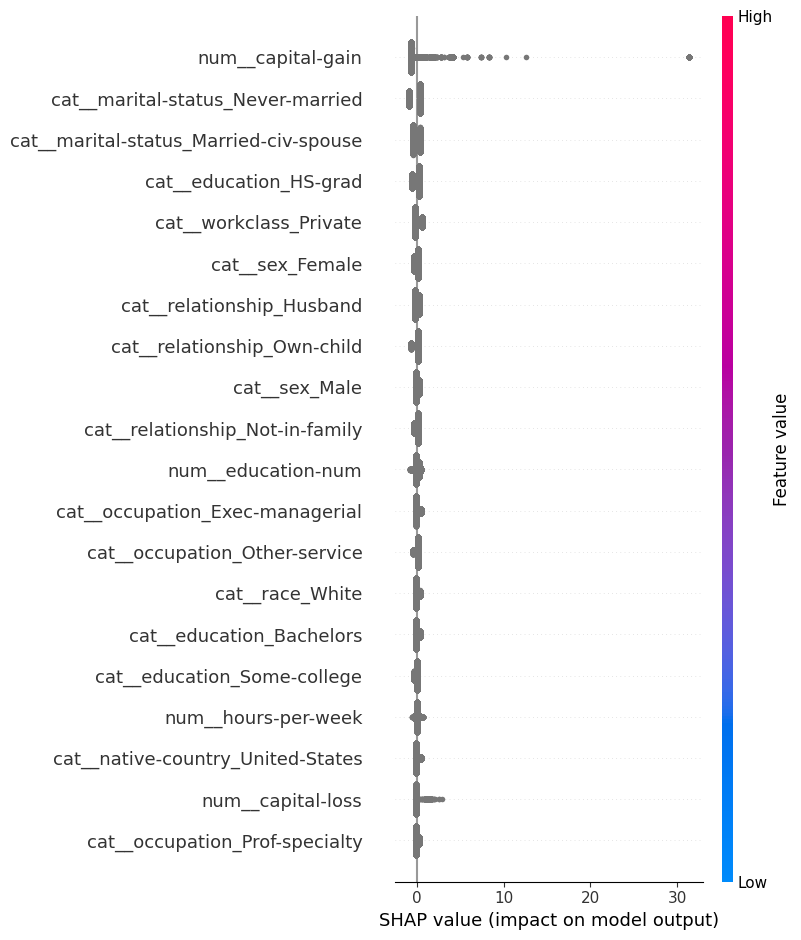

In [6]:
X_train_processed=model.named_steps["prep"].transform(X_train)

feature_names=model.named_steps["prep"].get_feature_names_out()

explainer=shap.LinearExplainer(
    model.named_steps["model"],
    X_train_processed
)

X_test_processed=model.named_steps["prep"].transform(X_test)

shap_values=explainer.shap_values(X_test_processed)

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

In [7]:
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric

fair_df=df.copy()

fair_df["income"]=(fair_df["class"]==">50K").astype(int)

fair_df["gender"]=fair_df["sex"].map({
    "Female":0,
    "Male":1
})

fair_df=fair_df[["income","gender"]].dropna()

dataset=BinaryLabelDataset(
    favorable_label=1,
    unfavorable_label=0,
    df=fair_df,
    label_names=["income"],
    protected_attribute_names=["gender"]
)

metric=BinaryLabelDatasetMetric(
    dataset,
    privileged_groups=[{"gender":1}],
    unprivileged_groups=[{"gender":0}]
)

print("Disparate Impact")

print(metric.disparate_impact())

pip install 'aif360[inFairness]'


Disparate Impact
0.3596552625800337


In [8]:
from aif360.algorithms.preprocessing import Reweighing

rw=Reweighing(
    privileged_groups=[{"gender":1}],
    unprivileged_groups=[{"gender":0}]
)

dataset_transformed=rw.fit_transform(dataset)

metric_after=BinaryLabelDatasetMetric(
    dataset_transformed,
    privileged_groups=[{"gender":1}],
    unprivileged_groups=[{"gender":0}]
)

print("Before:",metric.disparate_impact())

print("After:",metric_after.disparate_impact())

Before: 0.3596552625800337
After: 1.0000000000000004
